In [25]:
import pandas as pd
import dask.dataframe as dd 

# 1. IMPORTACIÓN (Punto 2) - Usamos DASK para el archivo pesado
print("Cargando datos con Dask...")
# Dask no carga todo en memoria de golpe, crea un "grafo" de la operación
ddf_ventas = dd.read_csv('../data/train.csv', dtype={'StateHoliday': 'object'})

# Calculamos y lo pasamos a Pandas (compute) solo cuando ya es manejable
df_ventas = ddf_ventas.compute() 
df_tiendas = pd.read_csv('../data/store.csv') # Este es pequeño, usamos Pandas

print("✅ Datos cargados. Filas en ventas:", len(df_ventas))

Cargando datos con Dask...
✅ Datos cargados. Filas en ventas: 1017209


In [26]:
import requests
import pandas as pd

# --- REQUISITO: OBTENCIÓN DE DATOS VÍA API Y JSON ---
print("Obteniendo calendario de festivos de Alemania (API)...")

# Llamamos a una API pública de festivos (Nager.Date)
url_api = "https://date.nager.at/api/v3/PublicHolidays/2015/DE"
respuesta = requests.get(url_api)

if respuesta.status_code == 200:
    # Convertimos el JSON de la API directamente a un DataFrame de Pandas
    festivos_json = respuesta.json()
    df_festivos = pd.DataFrame(festivos_json)
    
    print("✅ ¡Datos JSON cargados con éxito desde la API!")
    display(df_festivos[['date', 'localName', 'name']].head())
else:
    print(f"Error al conectar con la API. Código: {respuesta.status_code}")

Obteniendo calendario de festivos de Alemania (API)...
✅ ¡Datos JSON cargados con éxito desde la API!


,date,localName,name
0,2015-01-01,Neujahr,New Year's Day
1,2015-01-06,Heilige Drei Könige,Epiphany
2,2015-04-03,Karfreitag,Good Friday
3,2015-04-05,Ostersonntag,Easter Sunday
4,2015-04-06,Ostermontag,Easter Monday


In [27]:
# 2. TRANSFORMACIONES (Punto 3) - Cruce de datos 
df_master = pd.merge(df_ventas, df_tiendas, on='Store', how='left')

# Convertimos la fecha a formato DateTime para poder ordenar luego
df_master['Date'] = pd.to_datetime(df_master['Date'], format='%Y-%m-%d')

# 3. MAPEO (Punto 4) - Convertimos códigos en nombres legibles
dict_tiendas = {'a': 'Pequeña', 'b': 'Mediana', 'c': 'Grande', 'd': 'Extra'}
df_master['StoreType_Name'] = df_master['StoreType'].map(dict_tiendas)

print("✅ Tablas unidas en df_master correctamente.")

✅ Tablas unidas en df_master correctamente.


In [28]:
# 5. ORDENACIÓN (Punto 5 de la rúbrica)

# Ordenar por fecha y por volumen de ventas (de mayor a menor)
df_sorted = df_master.sort_values(by=['Date', 'Sales'], ascending=[True, False])

print("✅ Datos ordenados por fecha y ventas.")

# Ver el top 10 de registros con más ventas
df_sorted[['Store', 'Date', 'Sales', 'Customers', 'StoreType_Name']].head(10)

# Uso explícito de .apply() para cumplir con la rúbrica
def categorizar_distancia(distancia):
    if pd.isna(distancia):
        return 'Desconocido'
    elif distancia < 1000:
        return 'Competencia Fuerte (Cerca)'
    else:
        return 'Competencia Débil (Lejos)'

# Aplicamos la función a la columna
df_master['Nivel_Competencia'] = df_master['CompetitionDistance'].apply(categorizar_distancia)

print("✅ Columna creada usando .apply()")

✅ Datos ordenados por fecha y ventas.
✅ Columna creada usando .apply()


📊 Resumen por Tipo de Tienda:
                Ventas_Totales  Ventas_Promedio  Dias_con_Promo
StoreType_Name                                                 
Pequeña             3165334859      5738.179710          210504
Extra               1765392943      5641.819243          119286
Grande               783221426      5723.629246           52244
Mediana              159231395     10058.837334            6046


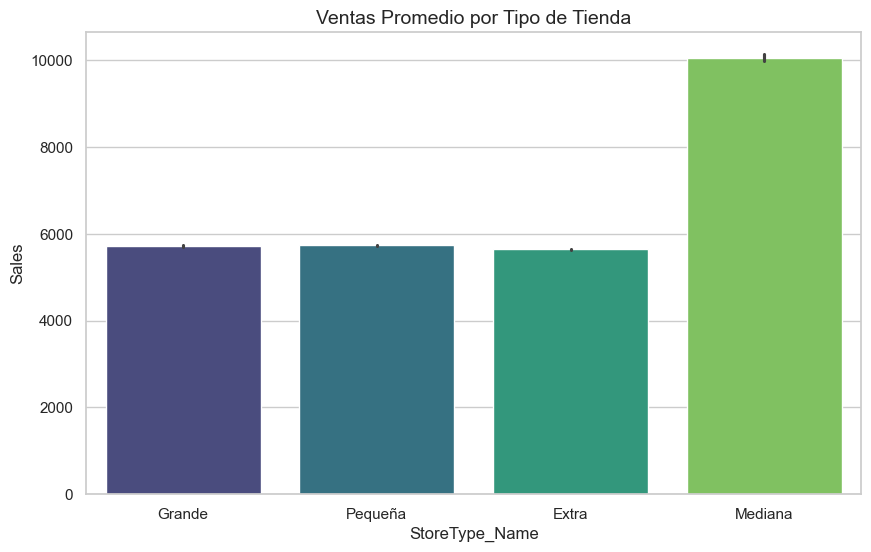

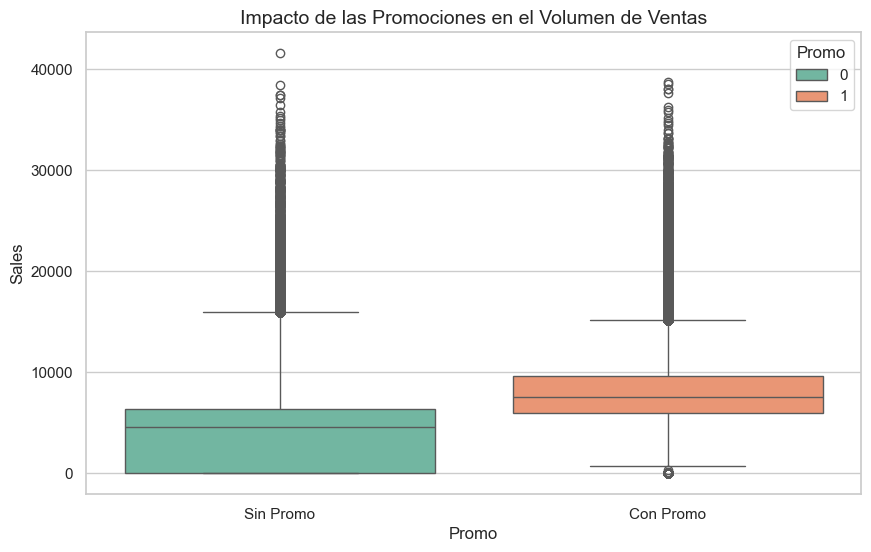

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Demostración de agrupaciones complejas (Group by + Aggregation)
df_resumen = df_master.groupby('StoreType_Name').agg(
    Ventas_Totales=('Sales', 'sum'),
    Ventas_Promedio=('Sales', 'mean'),
    Dias_con_Promo=('Promo', 'sum')
).sort_values(by='Ventas_Totales', ascending=False) # sort_values es el "arrange" de Pandas

print("📊 Resumen por Tipo de Tienda:")
print(df_resumen)

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 6. VISUALIZACIÓN (Punto 6)
# Gráfico 1: ¿Qué tipo de tienda factura más en promedio?
plt.figure(figsize=(10, 6))
sns.barplot(data=df_master, x='StoreType_Name', y='Sales', palette='viridis', hue='StoreType_Name', legend=False)
plt.title('Ventas Promedio por Tipo de Tienda', fontsize=14)
plt.show()

# Gráfico 2: Impacto de las promociones en las ventas
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_master, x='Promo', y='Sales', palette='Set2', hue='Promo')
plt.title('Impacto de las Promociones en el Volumen de Ventas', fontsize=14)
plt.xticks([0, 1], ['Sin Promo', 'Con Promo'])
plt.show()

1. Python: Preparando datos para enviar a R...
2. Python: Escribiendo el script de R...
3. Ejecutando motor de R en segundo plano...
✅ ¡Gráfico de R generado con éxito!


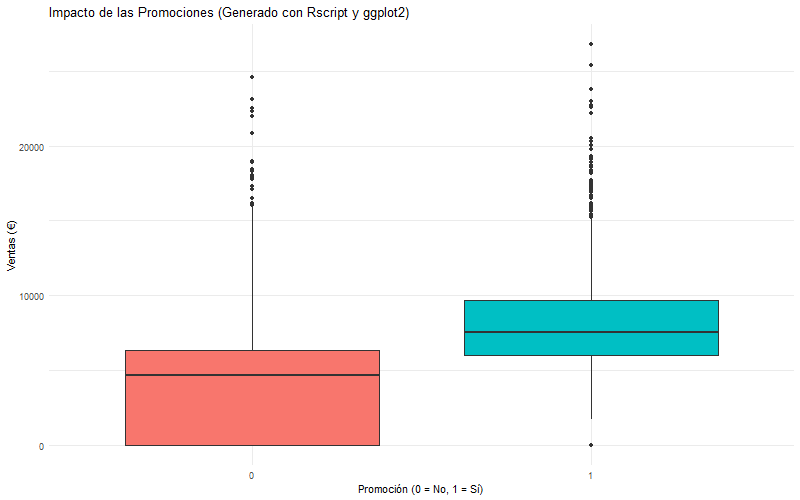

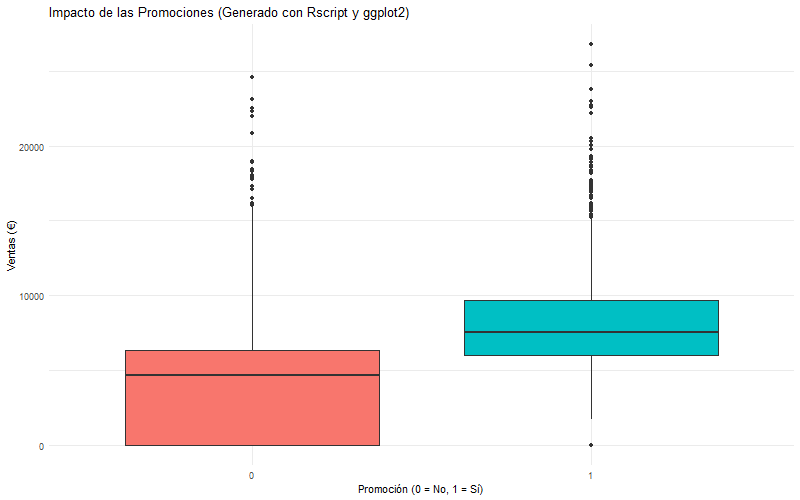

5. Limpiando archivos temporales...
🧹 Taller limpio. ¡Aquí no ha pasado nada!


In [30]:
import pandas as pd
import subprocess
from IPython.display import Image, display
import os

print("1. Python: Preparando datos para enviar a R...")
# Guardamos una muestra de los datos en un CSV para que R lo lea
df_master[['Promo', 'Sales']].dropna().sample(5000, random_state=42).to_csv('datos_para_r.csv', index=False)

print("2. Python: Escribiendo el script de R...")
# Creamos el código de R puro como texto
codigo_r = """
# Cargamos ggplot2 (lo instala si no lo tienes)
if (!require("ggplot2")) install.packages("ggplot2", repos="http://cran.us.r-project.org")
library(ggplot2)

# Leemos los datos que nos ha mandado Python
datos <- read.csv('datos_para_r.csv')

# Dibujamos el gráfico y lo guardamos como imagen
png('grafico_r.png', width=800, height=500)
ggplot(datos, aes(x=factor(Promo), y=Sales, fill=factor(Promo))) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title="Impacto de las Promociones (Generado con Rscript y ggplot2)",
    x="Promoción (0 = No, 1 = Sí)",
    y="Ventas (€)"
  ) +
  theme(legend.position="none")
invisible(dev.off())
"""

# Guardamos ese texto como un archivo .R de verdad
with open("script_analisis.R", "w", encoding="utf-8") as f:
    f.write(codigo_r)

print("3. Ejecutando motor de R en segundo plano...")
# Usamos la ruta exacta donde he visto en tu error que tienes instalado R
ruta_rscript = r"C:\Program Files\R\R-4.4.1\bin\Rscript.exe"

try:
    # Python llama al sistema operativo para que ejecute R
    subprocess.run([ruta_rscript, "script_analisis.R"], check=True)
    print("✅ ¡Gráfico de R generado con éxito!")
    
    # 4. Python recoge el resultado y lo muestra
    display(Image(filename='grafico_r.png'))

    # 4. Python recoge el resultado y lo muestra
    display(Image(filename='grafico_r.png'))
    
    # 5. Modo "Misión Imposible": Destruir pruebas
    print("5. Limpiando archivos temporales...")
    os.remove('datos_para_r.csv')
    os.remove('script_analisis.R')
    os.remove('grafico_r.png')
    print("🧹 Taller limpio. ¡Aquí no ha pasado nada!")
    
except Exception as e:
    print(f"❌ Error: {e}")
    
except Exception as e:
    print(f"❌ Error al intentar ejecutar R: {e}")

In [31]:
from dagster import asset, Definitions
import pandas as pd
import os

@asset
def raw_sales_data():
    """Carga de los datos crudos de ventas (Punto 2)."""
    # Usamos os.path para que no haya errores de rutas
    path = os.path.join('data', 'train.csv')
    return pd.read_csv(path, low_memory=False, nrows=100000)

@asset
def raw_store_data():
    """Carga de los datos de las tiendas (Punto 2)."""
    path = os.path.join('data', 'store.csv')
    return pd.read_csv(path)

@asset
def integrated_data(raw_sales_data, raw_store_data):
    """Cruce de datos y transformaciones (Puntos 3, 4 y 5)."""
    # Unimos tablas (Punto 3) 
    df = pd.merge(raw_sales_data, raw_store_data, on='Store', how='left')
    
    # Arreglamos fechas
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    
    # Mapeo (Punto 4) 
    dict_tiendas = {'a': 'Pequeña', 'b': 'Mediana', 'c': 'Grande', 'd': 'Extra'}
    df['StoreType_Name'] = df['StoreType'].map(dict_tiendas)
    
    # Ordenación (Punto 5) 
    df = df.sort_values(by=['Date', 'Sales'], ascending=[True, False])
    
    return df

# Esta es la parte que le faltaba a Dagster para no dar error:
defs = Definitions(
    assets=[raw_sales_data, raw_store_data, integrated_data]
)

In [32]:
# --- EXPORTAMOS LOS DATOS LIMPIOS PARA EL SIGUIENTE NOTEBOOK ---
print("Guardando df_master limpio para el cuaderno de entrenamiento...")

# Usamos formato .parquet porque es muchísimo más rápido y ligero que un CSV
df_master.to_parquet('../data/df_master_limpio.parquet', index=False)

print("✅ Datos guardados en data/df_master_limpio.parquet")

Guardando df_master limpio para el cuaderno de entrenamiento...
✅ Datos guardados en data/df_master_limpio.parquet
